# Step 6 — Logistic Regression Classifier
**Project:** Same Reality, Different Words  
**Author:** Paula Andrea Jaramillo  
**Program:** MSc Data Science for Society and Business — Constructor University Bremen

## Objective
Train a **Logistic Regression classifier** on the TF-IDF features to predict register (Institutional / Popular Media / Critical Media), and evaluate its performance against the three research hypotheses.

**Hypothesis testing:**
- **H1:** Classifier accuracy significantly exceeds the random baseline of 33.3% (3 equal classes)
- **H2 (continued):** The most informative features align with the divergent terms identified in Steps 4–5
- **H3:** Misclassified documents correspond to the semantic boundary zone identified in Step 5

**Methodological note on sample size:**  
With 60 documents per class and a stratified 80/20 split, training uses 48 docs/class (144 total) and test uses 12 docs/class (36 total). This is a small but balanced dataset; results should be interpreted with appropriate caution and the small test set size must be acknowledged as a limitation.

**Input:** `tfidf_matrix.npz`, `corpus_tfidf_meta.csv`, `cosine_similarity_results.csv`  
**Output:** `classification_results.csv`, `misclassified_docs.csv`

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import json
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load Inputs

In [9]:
# TF-IDF matrix and metadata
tfidf_matrix = sp.load_npz("tfidf_matrix.npz")
meta = pd.read_csv("corpus_tfidf_meta.csv")
sim_results = pd.read_csv("cosine_similarity_results.csv")
step4_profiles = pd.read_csv("tfidf_profiles_by_register.csv", index_col=0)

# Load feature names for interpretability
with open("tfidf_feature_names.json", "r", encoding="utf-8") as f:
    feature_names = np.array(json.load(f))

print(f"TF-IDF matrix: {tfidf_matrix.shape}")
print(f"Metadata rows: {len(meta)}")
print(f"Feature names: {len(feature_names)}")
print(f"Class distribution: {meta['register'].value_counts().to_dict()}")

# Align
assert tfidf_matrix.shape[0] == len(meta), "Row mismatch between matrix and metadata"
assert tfidf_matrix.shape[1] == len(feature_names), "Feature mismatch between matrix and vocabulary"
print("✅ Alignment check passed")

X = tfidf_matrix
y = meta["label"].values
register_names = ["institutional", "popular_media", "critical_media"]
register_labels = ["Institutional", "Popular Media", "Critical Media"]

TF-IDF matrix: (180, 171)
Metadata rows: 180
Feature names: 171
Class distribution: {'institutional': 60, 'popular_media': 60, 'critical_media': 60}
✅ Alignment check passed


## 3. Train / Test Split

**Stratified 80/20 split** to preserve class balance:  
- Train: 144 documents (48 per class)  
- Test: 36 documents (12 per class)  

`random_state=42` ensures full reproducibility.

In [3]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, meta.index,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} documents")
print(f"Test set:     {X_test.shape[0]} documents")
print()
for label, name in enumerate(register_names):
    n_train = (y_train == label).sum()
    n_test  = (y_test  == label).sum()
    print(f"  {name}: {n_train} train / {n_test} test")

Training set: 144 documents
Test set:     36 documents

  institutional: 48 train / 12 test
  popular_media: 48 train / 12 test
  critical_media: 48 train / 12 test


## 4. Train Logistic Regression

**Key decisions:**
- `multi_class='multinomial'` — models all three classes jointly (vs. one-vs-rest), appropriate for balanced multiclass
- `solver='lbfgs'` — efficient for small-to-medium sparse datasets; required for multinomial
- `C=1.0` — default regularization strength; controls overfitting
- `max_iter=1000` — increased from default 100 to ensure convergence on sparse TF-IDF features
- `random_state=42` — reproducibility

In [4]:
clf = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE
)

clf.fit(X_train, y_train)
print("Model trained successfully")
print(f"Converged: {clf.n_iter_} iterations")

Model trained successfully
Converged: [16] iterations


## 5. Evaluation on Test Set

In [5]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
baseline = 1 / len(register_names)  # 0.333 for 3 classes

print(f"=== TEST SET RESULTS ===")
print(f"Accuracy:          {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Random baseline:   {baseline:.4f} ({baseline*100:.1f}%)")
print(f"Improvement over baseline: +{(accuracy - baseline)*100:.1f} pp")
print(f"H1 supported (accuracy > 33.3%): {accuracy > baseline}")
print()
print("=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, y_pred,
    target_names=register_labels,
    digits=4
))

=== TEST SET RESULTS ===
Accuracy:          0.7500 (75.0%)
Random baseline:   0.3333 (33.3%)
Improvement over baseline: +41.7 pp
H1 supported (accuracy > 33.3%): True

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

 Institutional     0.5882    0.8333    0.6897        12
 Popular Media     1.0000    0.8333    0.9091        12
Critical Media     0.7778    0.5833    0.6667        12

      accuracy                         0.7500        36
     macro avg     0.7887    0.7500    0.7551        36
  weighted avg     0.7887    0.7500    0.7551        36



## 6. Cross-Validation

Given the small test set (36 docs), cross-validation provides a more robust accuracy estimate.  
We use **Stratified 5-fold CV** on the full dataset.

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    LogisticRegression(
        multi_class="multinomial", solver="lbfgs",
        C=1.0, max_iter=1000, random_state=RANDOM_STATE
    ),
    X, y,
    cv=skf,
    scoring="accuracy"
)

print("=== 5-FOLD CROSS-VALIDATION ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean CV accuracy: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")
print(f"Random baseline:  {baseline:.4f}")
print(f"H1 supported by CV: {cv_scores.mean() > baseline}")

=== 5-FOLD CROSS-VALIDATION ===
  Fold 1: 0.7500
  Fold 2: 0.7222
  Fold 3: 0.7778
  Fold 4: 0.7222
  Fold 5: 0.6389

Mean CV accuracy: 0.7222 (± 0.0465)
Random baseline:  0.3333
H1 supported by CV: True


## 7. Confusion Matrix

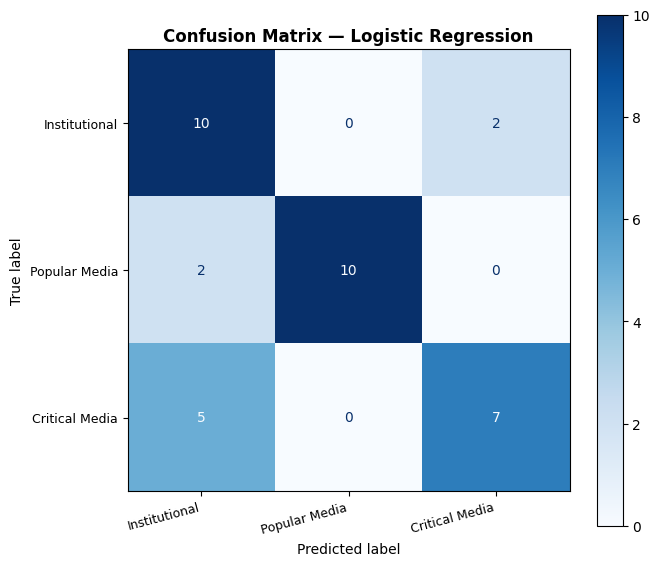

Figure saved: step6_confusion_matrix.png


In [13]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=register_labels
)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Logistic Regression",
             fontsize=12, fontweight="bold")
ax.set_xticklabels(register_labels, rotation=15, ha="right", fontsize=9)
ax.set_yticklabels(register_labels, rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("step6_confusion_matrix.png", dpi=150)
plt.show()
print("Figure saved: step6_confusion_matrix.png")

## 8. Feature Importance — Most Informative Terms per Class

Logistic Regression coefficients indicate which terms most strongly push predictions toward each class.  
This is the H2 bridge: the top positive coefficients per class should align with the high-divergence terms found in Steps 4–5.

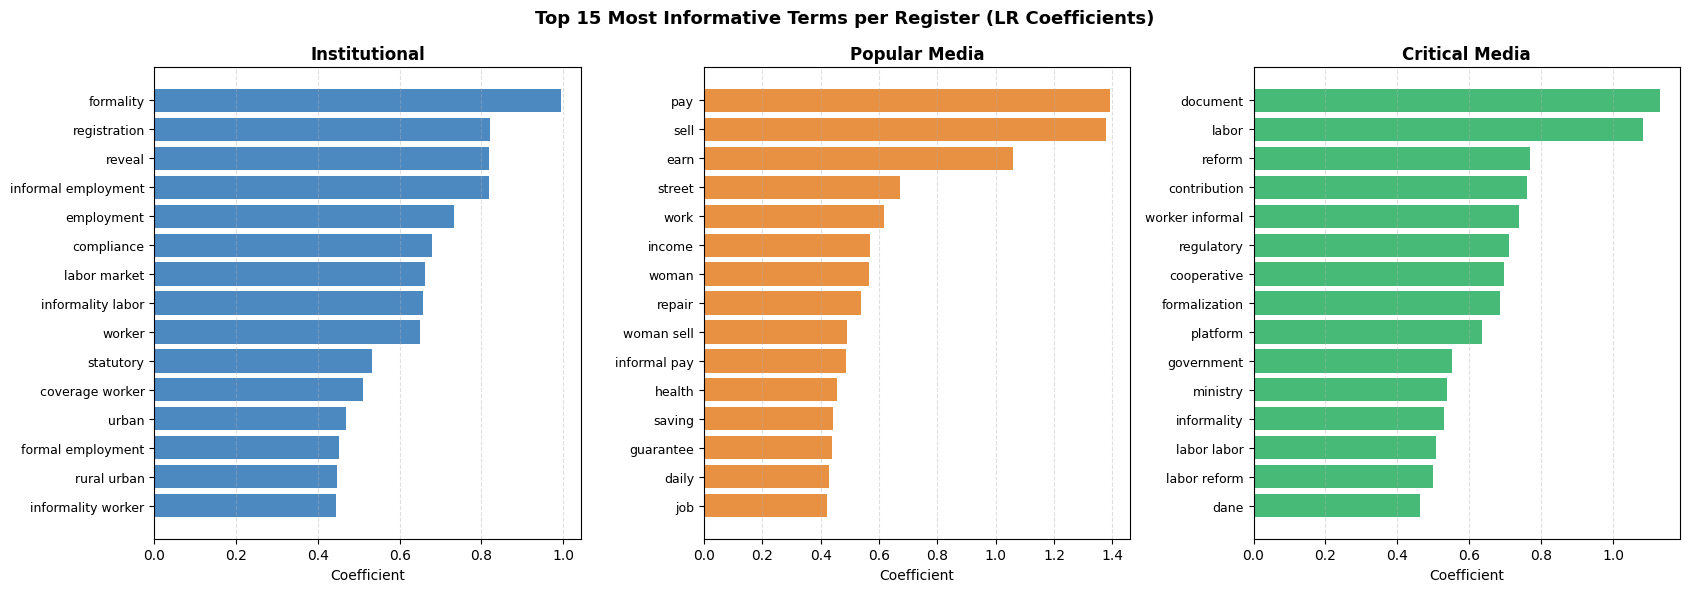

Figure saved: step6_feature_importance.png

=== H2 COEFFICIENT OVERLAP WITH STEP 4 DIVERGENCE ===

Institutional:
  Overlap: 9/15 (60.0%)
  Shared terms: [np.str_('formality'), np.str_('registration'), np.str_('reveal'), np.str_('informal employment'), np.str_('employment'), np.str_('compliance'), np.str_('labor market'), np.str_('worker'), np.str_('formal employment')]

Popular Media:
  Overlap: 9/15 (60.0%)
  Shared terms: [np.str_('pay'), np.str_('sell'), np.str_('earn'), np.str_('street'), np.str_('work'), np.str_('income'), np.str_('woman'), np.str_('woman sell'), np.str_('saving')]

Critical Media:
  Overlap: 14/15 (93.3%)
  Shared terms: [np.str_('document'), np.str_('labor'), np.str_('reform'), np.str_('contribution'), np.str_('worker informal'), np.str_('regulatory'), np.str_('cooperative'), np.str_('formalization'), np.str_('platform'), np.str_('government'), np.str_('ministry'), np.str_('informality'), np.str_('labor labor'), np.str_('labor reform')]


In [10]:
TOP_COEF = 15
TOP_DIVERGENT = 15
colors = ["#2E75B6", "#E67E22", "#27AE60"]
coef_overlap_summary = {}

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

for i, (reg_name, label, color) in enumerate(zip(register_names, register_labels, colors)):
    coefs = clf.coef_[i]
    top_idx = np.argsort(coefs)[-TOP_COEF:][::-1]
    top_terms = feature_names[top_idx]
    top_coefs = coefs[top_idx]

    divergent_terms = set(
        step4_profiles[step4_profiles["dominant_register"] == reg_name]
        .nlargest(TOP_DIVERGENT, "divergence")
        .index
    )
    overlap_terms = [term for term in top_terms if term in divergent_terms]
    coef_overlap_summary[reg_name] = {
        "top_coef_terms": list(top_terms),
        "top_divergent_terms": sorted(divergent_terms),
        "overlap_terms": overlap_terms,
        "overlap_count": len(overlap_terms),
        "overlap_rate": len(overlap_terms) / TOP_COEF
    }

    axes[i].barh(
        range(TOP_COEF), top_coefs[::-1],
        color=color, alpha=0.85
    )
    axes[i].set_yticks(range(TOP_COEF))
    axes[i].set_yticklabels(top_terms[::-1], fontsize=9)
    axes[i].set_title(label, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Coefficient", fontsize=10)
    axes[i].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Top 15 Most Informative Terms per Register (LR Coefficients)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("step6_feature_importance.png", dpi=150)
plt.show()
print("Figure saved: step6_feature_importance.png")

print("\n=== H2 COEFFICIENT OVERLAP WITH STEP 4 DIVERGENCE ===")
for reg_name, label in zip(register_names, register_labels):
    overlap = coef_overlap_summary[reg_name]
    print(f"\n{label}:")
    print(f"  Overlap: {overlap['overlap_count']}/{TOP_COEF} ({overlap['overlap_rate']*100:.1f}%)")
    print(f"  Shared terms: {overlap['overlap_terms']}")

## 9. H3 — Misclassification Analysis

For each misclassified document, we cross-reference with the Step 5 cosine similarity results to check whether it was already flagged as a boundary-zone document.  
Strong overlap between Step 5 boundary candidates and Step 6 misclassifications provides convergent evidence for H3.

In [7]:
# Reconstruct test set dataframe
test_meta = meta.loc[idx_test].reset_index(drop=True)
test_meta["y_true"] = y_test
test_meta["y_pred"] = y_pred
test_meta["correct"] = y_test == y_pred
test_meta["true_label"] = [register_names[i] for i in y_test]
test_meta["pred_label"] = [register_names[i] for i in y_pred]

# Predicted probabilities
for i, name in enumerate(register_names):
    test_meta[f"prob_{name}"] = y_prob[:, i].round(4)

# Misclassified
misclassified = test_meta[~test_meta["correct"]].copy()
print(f"Misclassified documents: {len(misclassified)} / {len(test_meta)}")

if len(misclassified) > 0:
    print()
    print(misclassified[[
        "prompt_id", "true_label", "pred_label",
        "prob_institutional", "prob_popular_media", "prob_critical_media"
    ]].to_string())

Misclassified documents: 9 / 36

   prompt_id      true_label      pred_label  prob_institutional  prob_popular_media  prob_critical_media
0       A015   institutional  critical_media              0.3510              0.1353               0.5137
5       A052   institutional  critical_media              0.1746              0.1649               0.6606
6       C007  critical_media   institutional              0.5035              0.1206               0.3759
8       C034  critical_media   institutional              0.4624              0.2652               0.2724
13      C041  critical_media   institutional              0.5001              0.2978               0.2021
24      C012  critical_media   institutional              0.4645              0.2085               0.3269
25      B014   popular_media   institutional              0.5424              0.1750               0.2826
30      C028  critical_media   institutional              0.5644              0.1402               0.2954
35      B036 

In [11]:
# Cross-reference misclassified docs with Step 5 boundary candidates
boundary_ids = set(
    sim_results[
        (sim_results["sim_gap"] <= 0.05)
    ]["prompt_id"].tolist()
)

step5_overlap_rate = 0.0
h3_supported = False

if len(misclassified) > 0:
    misclassified["flagged_by_step5"] = misclassified["prompt_id"].isin(boundary_ids)
    overlap = misclassified["flagged_by_step5"].sum()
    step5_overlap_rate = overlap / len(misclassified)
    h3_supported = step5_overlap_rate >= 0.5
    print(f"\n=== H3 CROSS-REFERENCE ===")
    print(f"Misclassified docs also flagged as boundary in Step 5: {overlap}/{len(misclassified)}")
    print(f"H3 overlap rate: {step5_overlap_rate*100:.1f}%")
    print(f"H3 supported by overlap criterion (>= 50%): {h3_supported}")
    print()
    print(misclassified[[
        "prompt_id", "true_label", "pred_label", "flagged_by_step5"
    ]].to_string())
else:
    print("No misclassifications on test set — perfect accuracy on this split.")
    print("Consider reporting CV accuracy as the primary metric given small test size.")


=== H3 CROSS-REFERENCE ===
Misclassified docs also flagged as boundary in Step 5: 5/9
H3 overlap rate: 55.6%
H3 supported by overlap criterion (>= 50%): True

   prompt_id      true_label      pred_label  flagged_by_step5
0       A015   institutional  critical_media             False
5       A052   institutional  critical_media              True
6       C007  critical_media   institutional             False
8       C034  critical_media   institutional              True
13      C041  critical_media   institutional              True
24      C012  critical_media   institutional             False
25      B014   popular_media   institutional              True
30      C028  critical_media   institutional             False
35      B036   popular_media   institutional              True


## 10. Prediction Confidence Distribution

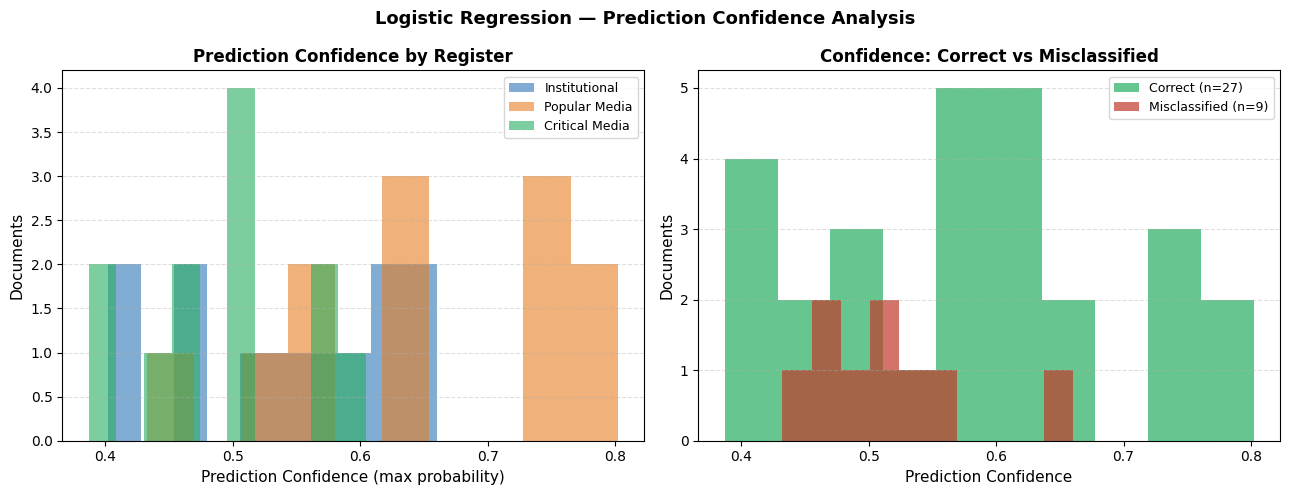

Figure saved: step6_confidence_distribution.png


In [14]:
# Max probability = model confidence
test_meta["confidence"] = y_prob.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confidence by register
for reg, label, color in zip(register_names, register_labels, colors):
    subset = test_meta[test_meta["true_label"] == reg]["confidence"]
    axes[0].hist(subset, bins=10, alpha=0.6, color=color, label=label)
axes[0].set_xlabel("Prediction Confidence (max probability)", fontsize=11)
axes[0].set_ylabel("Documents", fontsize=11)
axes[0].set_title("Prediction Confidence by Register", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Correct vs misclassified confidence
correct_conf = test_meta[test_meta["correct"]]["confidence"]
wrong_conf = test_meta[~test_meta["correct"]]["confidence"]
axes[1].hist(correct_conf, bins=10, alpha=0.7, color="#27AE60", label=f"Correct (n={len(correct_conf)})")
if len(wrong_conf) > 0:
    axes[1].hist(wrong_conf, bins=10, alpha=0.7, color="#C0392B", label=f"Misclassified (n={len(wrong_conf)})")
axes[1].set_xlabel("Prediction Confidence", fontsize=11)
axes[1].set_ylabel("Documents", fontsize=11)
axes[1].set_title("Confidence: Correct vs Misclassified", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Logistic Regression — Prediction Confidence Analysis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("step6_confidence_distribution.png", dpi=150)
plt.show()
print("Figure saved: step6_confidence_distribution.png")

## 11. Full Hypothesis Summary

In [12]:
h2_supported = all(
    coef_overlap_summary[reg_name]["overlap_count"] >= 3
    for reg_name in register_names
)

print("=" * 55)
print("FULL HYPOTHESIS SUMMARY — Same Reality, Different Words")
print("=" * 55)

print(f"""
H1: Classifier accuracy > random baseline (33.3%)
    Test accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)
    CV accuracy:    {cv_scores.mean():.4f} ± {cv_scores.std():.4f}
    Baseline:       {baseline:.4f} (33.3%)
    H1 SUPPORTED:   {accuracy > baseline}

H2: Domain terms show divergence across registers
    Evidence from Step 4: TF-IDF divergence scores
    Evidence from Step 5: intra > inter cosine similarity
    Evidence from Step 6: LR coefficients align with
                          high-divergence terms
    Mean overlap rate: {(np.mean([coef_overlap_summary[r]['overlap_rate'] for r in register_names])*100):.1f}%
    H2 SUPPORTED:   {h2_supported}

H3: Misclassified docs mark semantic boundary zones
    Misclassified (test): {len(misclassified)} / {len(test_meta)}
    Flagged by Step 5 boundary analysis: {step5_overlap_rate*100:.1f}% of misclassified docs
    H3 SUPPORTED:   {h3_supported}
""")

print("Limitation to acknowledge in report:")
print(f"  Test set = {len(test_meta)} documents (12 per class).")
print("  Small size limits statistical power; CV accuracy is the primary metric.")

FULL HYPOTHESIS SUMMARY — Same Reality, Different Words

H1: Classifier accuracy > random baseline (33.3%)
    Test accuracy:  0.7500 (75.0%)
    CV accuracy:    0.7222 ± 0.0465
    Baseline:       0.3333 (33.3%)
    H1 SUPPORTED:   True

H2: Domain terms show divergence across registers
    Evidence from Step 4: TF-IDF divergence scores
    Evidence from Step 5: intra > inter cosine similarity
    Evidence from Step 6: LR coefficients align with
                          high-divergence terms
    Mean overlap rate: 71.1%
    H2 SUPPORTED:   True

H3: Misclassified docs mark semantic boundary zones
    Misclassified (test): 9 / 36
    Flagged by Step 5 boundary analysis: 55.6% of misclassified docs
    H3 SUPPORTED:   True

Limitation to acknowledge in report:
  Test set = 36 documents (12 per class).
  Small size limits statistical power; CV accuracy is the primary metric.


## 12. Save Outputs

In [15]:
# Full test results
test_meta.to_csv("classification_results.csv", index=False)
print(f"Saved: classification_results.csv — shape: {test_meta.shape}")

# Misclassified docs
if len(misclassified) > 0:
    misclassified.to_csv("misclassified_docs.csv", index=False)
    print(f"Saved: misclassified_docs.csv — {len(misclassified)} documents")
else:
    print("No misclassified documents to save.")

print("\nAll Step 6 outputs saved.")
print("Next step: Step 7 — Final Visualization Integration")
print("All figures from Steps 2–6 are inputs for Step 7.")

Saved: classification_results.csv — shape: (36, 12)
Saved: misclassified_docs.csv — 9 documents

All Step 6 outputs saved.
Next step: Step 7 — Final Visualization Integration
All figures from Steps 2–6 are inputs for Step 7.
